# HST optical and near-UV synthetic CMDs

This notebook:

- builds merged-model SPISEA isochrones from 1 to 20 Myr;
- loads the sigma=0.1, epsilon_ff=0.03, seed 00 simulation;
- evaluates the cluster at 5 Myr;
- produces three HST/WFC3 UVIS CMDs:

  1. F555W - F814W versus F814W;
  2. F606W - F814W versus F814W;
  3. F336W - F814W versus F814W.

Isochrone age is encoded continuously with a shared colormap and colorbar.

HST filters are supplied to SPISEA as pysynphot OBSMODE strings, for
example ``wfc3,uvis1,f336w``.

In [1]:
from __future__ import annotations

import contextlib
import io
import math
import os
import shutil
import sys
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Column, Table
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

from spisea import atmospheres, reddening, synthetic
from nbody6tools import Reader
from nbody62spisea import converter

sys.path.append("/home/wyz5rge/synthetic-cmd-dev/cmd_generator")
import interpolator  # noqa: E402

/home/wyz5rge/.venv/nbody/lib/python3.11/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /home/wyz5rge/SPISEA/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


particles.bound_subset and particles.bound_indexes will raise ImportError


## Configuration

In [2]:
UPDATED_MERGED_ROOT = Path(
    "/home/wyz5rge/SPISEA/evolution/merged/"
    "baraffe_pisa_ekstrom_parsec/"
)

SIMULATION_PATH = Path(
    "/standard/Tan_JC/backup_protoclusters/multiples/M3000new/"
    "sigma0p1/fiducial/sfe_ff003/00"
)

SNAPSHOT_TIME_MYR = 5.0

ISO_CACHE_DIR = Path.cwd() / "hst_optical_uv_isochrone_cache"
OUTPUT_DIR = Path.cwd() / "hst_optical_uv_cmd_outputs"

RESET_ISO_CACHE = False
SAVE_FIGURES = True
SHOW_FIGURES = True

USE_ROTATING_MERGED = False
AKS = 0.0
DISTANCE_PC = 410.0
METALLICITY = 0.0

ATM_FUNC = atmospheres.get_BTSettl_2015_atmosphere
RED_LAW = reddening.RedLawHosek18b()

ISO_AGES_MYR = np.arange(1.0, 20.0 + 0.25, 0.5)
ISO_LOG_AGES = np.log10(ISO_AGES_MYR * 1.0e6)
PLOT_AGES_MYR = np.array([1.0, 2.0, 3.0, 5.0, 10.0, 15.0, 20.0])

CLIP_YOUNG_STARS_TO_GRID_MINIMUM = True

# Shared age-colormap configuration.
ISOCHRONE_CMAP_NAME = "coolwarm"
ISOCHRONE_CMAP = plt.get_cmap(ISOCHRONE_CMAP_NAME)
ISOCHRONE_NORM = Normalize(
    vmin=float(np.min(PLOT_AGES_MYR)),
    vmax=float(np.max(PLOT_AGES_MYR)),
)

ISOCHRONE_LINEWIDTH = 1.35
ISOCHRONE_ALPHA = 0.9

CLUSTER_MARKER_SIZE = 8
CLUSTER_ALPHA = 0.45
CLUSTER_COLOR = "black"

HST_FILTERS = {
    "F336W": "wfc3,uvis1,f336w",
    "F555W": "wfc3,uvis1,f555w",
    "F606W": "wfc3,uvis1,f606w",
    "F814W": "wfc3,uvis1,f814w",
}

ALL_FILTERS = list(HST_FILTERS.values())


def photometric_column(filter_name: str) -> str:
    return f"m_hst_{filter_name.lower()}"


FILTER_KEYS = {
    name: photometric_column(name)
    for name in HST_FILTERS
}


CMD_DEFINITIONS = [
    {
        "blue": "F555W",
        "red": "F814W",
        "y": "F814W",
        "name": "F555W-F814W",
        "title": "Optical: F555W - F814W vs. F814W",
    },
    {
        "blue": "F606W",
        "red": "F814W",
        "y": "F814W",
        "name": "F606W-F814W",
        "title": "Optical: F606W - F814W vs. F814W",
    },
    {
        "blue": "F336W",
        "red": "F814W",
        "y": "F814W",
        "name": "F336W-F814W",
        "title": "Near-UV/optical: F336W - F814W vs. F814W",
    },
]

L_SUN_WATTS = 3.846e26

## Merged evolutionary-model reader

In [3]:
class MergedBaraffePisaEkstromParsecDAT:
    """Compatibility reader for merged ``iso_*.dat`` tracks."""

    def __init__(self, root_dir: Path | str, rot: bool = False):
        self.root_dir = Path(root_dir).expanduser().resolve()
        self.rot = bool(rot)

        self.model_dir = str(self.root_dir)
        self.z_list = [0.015]
        self.z_solar = 0.015
        self.mass_list: list[float] = []

        self.grid_dir = self.root_dir / (
            "z015_rot" if self.rot else "z015_norot"
        )

        if not self.grid_dir.is_dir():
            raise FileNotFoundError(
                f"Merged-model directory does not exist: {self.grid_dir}"
            )

        paths = sorted(self.grid_dir.glob("iso_*.dat"))
        if not paths:
            raise FileNotFoundError(
                f"No iso_*.dat files found in {self.grid_dir}"
            )

        self.age_file_map: dict[float, Path] = {}

        for path in paths:
            try:
                log_age = float(path.stem.split("_")[1])
            except (IndexError, ValueError):
                continue

            self.age_file_map[round(log_age, 2)] = path

        self.age_list = np.array(
            sorted(self.age_file_map),
            dtype=float,
        )

    def isochrone(
        self,
        age: float = 1.0e6,
        metallicity: float = 0.0,
    ) -> Table:
        log_age_requested = math.log10(age)

        if log_age_requested < self.age_list[0]:
            raise ValueError(
                f"Requested logAge={log_age_requested:.4f} is below "
                f"grid minimum {self.age_list[0]:.2f}."
            )

        if log_age_requested > self.age_list[-1]:
            raise ValueError(
                f"Requested logAge={log_age_requested:.4f} is above "
                f"grid maximum {self.age_list[-1]:.2f}."
            )

        idx = int(
            np.argmin(np.abs(self.age_list - log_age_requested))
        )
        selected_log_age = float(self.age_list[idx])
        iso_path = self.age_file_map[round(selected_log_age, 2)]

        dtype = [
            ("mass", "f8"),
            ("logT", "f8"),
            ("logL", "f8"),
            ("logg", "f8"),
            ("logT_WR", "f8"),
            ("mass_current", "f8"),
            ("phase", "i4"),
            ("model_ref", "U32"),
        ]

        data = np.genfromtxt(
            iso_path,
            comments="#",
            dtype=dtype,
            encoding="utf-8",
        )
        iso = Table(np.atleast_1d(data))

        is_wr = ~np.isclose(
            np.asarray(iso["logT"], dtype=float),
            np.asarray(iso["logT_WR"], dtype=float),
            rtol=0.0,
            atol=1.0e-8,
        )
        iso.add_column(Column(is_wr, name="isWR"))

        iso.meta["log_age"] = selected_log_age
        iso.meta["log_age_requested"] = log_age_requested
        iso.meta["metallicity_in"] = metallicity
        iso.meta["metallicity_act"] = 0.0
        iso.meta["source_file"] = str(iso_path)

        return iso

## General helpers

In [4]:
@dataclass
class IsochroneGrid:
    ages_myr: np.ndarray
    log_ages: np.ndarray
    isochrones: list
    coverage: pd.DataFrame


def prepare_directories() -> None:
    if RESET_ISO_CACHE and ISO_CACHE_DIR.exists():
        shutil.rmtree(ISO_CACHE_DIR)

    ISO_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def finish_figure(fig: plt.Figure, filename: str) -> None:
    if SAVE_FIGURES:
        fig.savefig(
            OUTPUT_DIR / filename,
            dpi=220,
            bbox_inches="tight",
        )

    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)


def get_iso_column(iso, name: str) -> np.ndarray:
    return np.asarray(iso.points[name], dtype=float)


def safe_interpolate(
    age_myr: float,
    mass: float,
    iso_grid: Sequence,
    log_age_arr: np.ndarray,
    filters: Sequence[str],
) -> np.ndarray | None:
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            with contextlib.redirect_stdout(io.StringIO()):
                with contextlib.redirect_stderr(io.StringIO()):
                    result = interpolator.interpolate(
                        age_myr,
                        mass,
                        iso_grid,
                        log_age_arr,
                        list(filters),
                    )

        if result is None:
            return None

        result = np.asarray(result, dtype=float)

        if result.size < 3 + len(filters):
            return None

        if not np.all(np.isfinite(result)):
            return None

        return result

    except Exception:
        return None


def make_age_mappable() -> ScalarMappable:
    """Return the shared ScalarMappable used by all isochrone colorbars."""
    mappable = ScalarMappable(
        norm=ISOCHRONE_NORM,
        cmap=ISOCHRONE_CMAP,
    )
    mappable.set_array(PLOT_AGES_MYR)
    return mappable

## Build or load the HST photometric isochrone grid

In [5]:
def build_isochrone_grid(evo_model) -> IsochroneGrid:
    isochrones = []
    records = []

    for age_myr, log_age in zip(ISO_AGES_MYR, ISO_LOG_AGES):
        print(f"Building/loading {age_myr:4.1f} Myr isochrone")

        try:
            iso = synthetic.IsochronePhot(
                log_age,
                AKS,
                DISTANCE_PC,
                metallicity=METALLICITY,
                evo_model=evo_model,
                atm_func=ATM_FUNC,
                red_law=RED_LAW,
                filters=ALL_FILTERS,
                iso_dir=str(ISO_CACHE_DIR),
            )

            missing = [
                key
                for key in FILTER_KEYS.values()
                if key not in iso.points.colnames
            ]

            if missing:
                raise KeyError(
                    "Photometric isochrone is missing expected columns "
                    f"{missing}. Existing columns are "
                    f"{iso.points.colnames}. Verify FILTER_KEYS against "
                    "the actual SPISEA output-column naming convention."
                )

            mass = get_iso_column(iso, "mass")
            isochrones.append(iso)

            records.append(
                {
                    "age_myr": age_myr,
                    "log_age": log_age,
                    "status": "success",
                    "n_points": len(iso.points),
                    "mass_min": np.nanmin(mass),
                    "mass_max": np.nanmax(mass),
                    "error": "",
                }
            )

        except Exception as exc:
            print(f"  FAILED: {exc}")
            isochrones.append(None)

            records.append(
                {
                    "age_myr": age_myr,
                    "log_age": log_age,
                    "status": "failed",
                    "n_points": 0,
                    "mass_min": np.nan,
                    "mass_max": np.nan,
                    "error": str(exc),
                }
            )

    return IsochroneGrid(
        ages_myr=ISO_AGES_MYR.copy(),
        log_ages=ISO_LOG_AGES.copy(),
        isochrones=isochrones,
        coverage=pd.DataFrame(records),
    )

In [6]:
prepare_directories()

if not SIMULATION_PATH.is_dir():
    raise FileNotFoundError(
        f"Simulation directory does not exist: {SIMULATION_PATH}"
    )

evo_model = MergedBaraffePisaEkstromParsecDAT(
    UPDATED_MERGED_ROOT,
    rot=USE_ROTATING_MERGED,
)

ISO_GRID = build_isochrone_grid(evo_model)
display(ISO_GRID.coverage)

failed = ISO_GRID.coverage[
    ISO_GRID.coverage["status"] != "success"
]

if len(failed) > 0:
    raise RuntimeError(
        "One or more HST photometric isochrones failed:\n"
        + failed[["age_myr", "error"]].to_string(index=False)
    )

Building/loading  1.0 Myr isochrone
Building/loading  1.5 Myr isochrone
Building/loading  2.0 Myr isochrone
Building/loading  2.5 Myr isochrone
Building/loading  3.0 Myr isochrone
Building/loading  3.5 Myr isochrone
Building/loading  4.0 Myr isochrone
Building/loading  4.5 Myr isochrone
Building/loading  5.0 Myr isochrone
Building/loading  5.5 Myr isochrone


Building/loading  6.0 Myr isochrone
Building/loading  6.5 Myr isochrone
Building/loading  7.0 Myr isochrone
Building/loading  7.5 Myr isochrone
Building/loading  8.0 Myr isochrone


Building/loading  8.5 Myr isochrone
Building/loading  9.0 Myr isochrone
Building/loading  9.5 Myr isochrone
Building/loading 10.0 Myr isochrone
Building/loading 10.5 Myr isochrone
Building/loading 11.0 Myr isochrone
Building/loading 11.5 Myr isochrone
Building/loading 12.0 Myr isochrone
Building/loading 12.5 Myr isochrone
Building/loading 13.0 Myr isochrone
Building/loading 13.5 Myr isochrone


Building/loading 14.0 Myr isochrone
Building/loading 14.5 Myr isochrone
Building/loading 15.0 Myr isochrone
Building/loading 15.5 Myr isochrone
Building/loading 16.0 Myr isochrone


Building/loading 16.5 Myr isochrone
Building/loading 17.0 Myr isochrone
Building/loading 17.5 Myr isochrone
Building/loading 18.0 Myr isochrone
Building/loading 18.5 Myr isochrone
Building/loading 19.0 Myr isochrone
Building/loading 19.5 Myr isochrone
Building/loading 20.0 Myr isochrone


,age_myr,log_age,status,n_points,mass_min,mass_max,error
0,1.0,6.000000,success,1178,0.01,500.000,
1,1.5,6.176091,success,1287,0.01,500.000,
2,2.0,6.301030,success,1330,0.01,500.000,
3,2.5,6.397940,success,2333,0.01,259.154,
4,3.0,6.477121,success,1856,0.01,116.520,
5,3.5,6.544068,success,1884,0.01,80.336,
6,4.0,6.602060,success,1704,0.01,58.761,
7,4.5,6.653213,success,1571,0.01,47.174,
8,5.0,6.698970,success,1529,0.01,39.109,
9,5.5,6.740363,success,1525,0.01,34.304,


## Load the 5 Myr N-body snapshot

In [7]:
def load_cluster_table(
    sim_path: Path | str,
    snapshot_time_myr: float,
) -> Table:
    sim_path = os.path.abspath(str(sim_path))

    if not sim_path.endswith("/"):
        sim_path += "/"

    snapshot = Reader.read_snapshot(
        sim_path,
        time=float(snapshot_time_myr),
    )
    snapshot.to_physical()

    return converter.to_spicea_table(snapshot)

In [8]:
cluster_table = load_cluster_table(
    SIMULATION_PATH,
    SNAPSHOT_TIME_MYR,
)

print(f"Loaded {len(cluster_table)} primary systems")
display(cluster_table[:5])

Loaded 2329 primary systems


mass,isMultiple,compMass,systemMass,e,log_a,age
float64,float64,object,float64,float64,float64,float64
0.07125772186202367,0.0,[],0.07125772186202367,nan,nan,4.386638557741293
0.41869354248046875,0.0,[],0.41869354248046875,nan,nan,4.972990989685059
0.37526202749596593,0.0,[],0.37526202749596593,nan,nan,2.5036653315719177
0.046876052589165364,0.0,[],0.046876052589165364,nan,nan,2.5054436211917888
0.03349046949146311,0.0,[],0.03349046949146311,nan,nan,2.5054436211917888


## Interpolate the snapshot into HST magnitudes

In [9]:
INTERPOLATED_COLUMNS = [
    "system_index",
    "mass",
    "age_myr",
    "age_used_myr",
    "age_clipped_to_grid",
    "teff",
    "luminosity_watts",
    "log_luminosity_lsun",
    "logg",
    "mag_F336W",
    "mag_F555W",
    "mag_F606W",
    "mag_F814W",
    "color_F555W_F814W",
    "color_F606W_F814W",
    "color_F336W_F814W",
]


def interpolate_cluster_snapshot(
    table: Table,
    grid: IsochroneGrid,
) -> pd.DataFrame:
    masses = np.asarray(table["mass"], dtype=float)
    ages_myr = np.asarray(table["age"], dtype=float)

    grid_age_min = float(grid.ages_myr.min())
    grid_age_max = float(grid.ages_myr.max())

    filter_names = list(HST_FILTERS)
    filter_keys = [FILTER_KEYS[name] for name in filter_names]

    rows = []
    counters = {
        "nonfinite_mass": 0,
        "nonfinite_age": 0,
        "younger_than_grid": 0,
        "older_than_grid": 0,
        "interpolation_failed": 0,
        "nonpositive_luminosity": 0,
        "retained": 0,
    }

    for system_index, (mass, age_myr) in enumerate(
        zip(masses, ages_myr)
    ):
        if not np.isfinite(mass):
            counters["nonfinite_mass"] += 1
            continue

        if not np.isfinite(age_myr):
            counters["nonfinite_age"] += 1
            continue

        age_used_myr = float(age_myr)
        age_clipped = False

        if age_used_myr < grid_age_min:
            counters["younger_than_grid"] += 1

            if CLIP_YOUNG_STARS_TO_GRID_MINIMUM:
                age_used_myr = grid_age_min
                age_clipped = True
            else:
                continue

        if age_used_myr > grid_age_max:
            counters["older_than_grid"] += 1
            continue

        result = safe_interpolate(
            age_used_myr,
            float(mass),
            grid.isochrones,
            grid.log_ages,
            filter_keys,
        )

        if result is None:
            counters["interpolation_failed"] += 1
            continue

        luminosity_watts = float(result[0])
        teff = float(result[1])
        logg = float(result[2])
        magnitudes = result[3:3 + len(filter_names)]

        if luminosity_watts <= 0:
            counters["nonpositive_luminosity"] += 1
            continue

        mag = {
            name: float(value)
            for name, value in zip(filter_names, magnitudes)
        }

        rows.append(
            {
                "system_index": system_index,
                "mass": float(mass),
                "age_myr": float(age_myr),
                "age_used_myr": age_used_myr,
                "age_clipped_to_grid": age_clipped,
                "teff": teff,
                "luminosity_watts": luminosity_watts,
                "log_luminosity_lsun": np.log10(
                    luminosity_watts / L_SUN_WATTS
                ),
                "logg": logg,
                "mag_F336W": mag["F336W"],
                "mag_F555W": mag["F555W"],
                "mag_F606W": mag["F606W"],
                "mag_F814W": mag["F814W"],
                "color_F555W_F814W": (
                    mag["F555W"] - mag["F814W"]
                ),
                "color_F606W_F814W": (
                    mag["F606W"] - mag["F814W"]
                ),
                "color_F336W_F814W": (
                    mag["F336W"] - mag["F814W"]
                ),
            }
        )
        counters["retained"] += 1

    df = pd.DataFrame(rows, columns=INTERPOLATED_COLUMNS)
    df.attrs["interpolation_counters"] = counters
    return df

In [10]:
df_cluster = interpolate_cluster_snapshot(
    cluster_table,
    ISO_GRID,
)

print(
    f"Retained {len(df_cluster)}/{len(cluster_table)} primary systems"
)
print(df_cluster.attrs["interpolation_counters"])

if df_cluster.empty:
    raise RuntimeError(
        "No stars survived HST interpolation. Inspect the accounting "
        "printed above and verify the filter-column names."
    )

display(df_cluster.head())

df_cluster.to_csv(
    OUTPUT_DIR / "sigma0p1_eff0p03_seed00_t5myr_hst_photometry.csv",
    index=False,
)

Retained 2329/2329 primary systems
{'nonfinite_mass': 0, 'nonfinite_age': 0, 'younger_than_grid': 397, 'older_than_grid': 0, 'interpolation_failed': 0, 'nonpositive_luminosity': 0, 'retained': 2329}


,system_index,mass,age_myr,age_used_myr,age_clipped_to_grid,teff,luminosity_watts,log_luminosity_lsun,logg,mag_F336W,mag_F555W,mag_F606W,mag_F814W,color_F555W_F814W,color_F606W_F814W,color_F336W_F814W
0,0,0.071258,4.386639,4.386639,False,2922.775,8.016446e+24,-1.681027,3.787,22.584,20.775,20.266,16.984,3.791,3.282,5.600
1,1,0.418694,4.972991,4.972991,False,3576.743,5.991171e+25,-0.807498,4.035,19.372,16.772,16.342,14.378,2.394,1.964,4.994
2,2,0.375262,2.503665,2.503665,False,3549.563,8.391677e+25,-0.661161,3.828,19.133,16.513,16.082,14.051,2.462,2.031,5.082
3,3,0.046876,2.505444,2.505444,False,2815.757,6.344373e+24,-1.782621,3.647,23.086,21.382,20.844,17.358,4.024,3.486,5.728
4,4,0.033490,2.505444,2.505444,False,2733.182,3.343409e+24,-2.060820,3.734,24.147,22.395,21.835,18.172,4.223,3.663,5.975


## CMD plotting helpers

In [11]:
def get_iso_cmd(
    iso,
    blue_filter: str,
    red_filter: str,
    y_filter: str,
) -> tuple[np.ndarray, np.ndarray]:
    blue = get_iso_column(iso, FILTER_KEYS[blue_filter])
    red = get_iso_column(iso, FILTER_KEYS[red_filter])
    y_mag = get_iso_column(iso, FILTER_KEYS[y_filter])

    color = blue - red

    good = np.isfinite(color) & np.isfinite(y_mag)
    return color[good], y_mag[good]


def get_cluster_cmd(
    df: pd.DataFrame,
    blue_filter: str,
    red_filter: str,
    y_filter: str,
) -> tuple[np.ndarray, np.ndarray]:
    blue = df[f"mag_{blue_filter}"].to_numpy(dtype=float)
    red = df[f"mag_{red_filter}"].to_numpy(dtype=float)
    y_mag = df[f"mag_{y_filter}"].to_numpy(dtype=float)

    color = blue - red
    good = np.isfinite(color) & np.isfinite(y_mag)
    return color[good], y_mag[good]


def plot_cmd_panel(
    ax: plt.Axes,
    definition: dict[str, str],
    grid: IsochroneGrid,
    df: pd.DataFrame,
) -> None:
    blue = definition["blue"]
    red = definition["red"]
    y_filter = definition["y"]

    for requested_age_myr in PLOT_AGES_MYR:
        idx = int(
            np.argmin(
                np.abs(grid.ages_myr - requested_age_myr)
            )
        )
        iso = grid.isochrones[idx]

        if iso is None:
            continue

        actual_age_myr = float(grid.ages_myr[idx])

        color, y_mag = get_iso_cmd(
            iso,
            blue,
            red,
            y_filter,
        )

        ax.plot(
            color,
            y_mag,
            color=ISOCHRONE_CMAP(
                ISOCHRONE_NORM(actual_age_myr)
            ),
            linewidth=ISOCHRONE_LINEWIDTH,
            alpha=ISOCHRONE_ALPHA,
            zorder=2,
        )

    cluster_color, cluster_y = get_cluster_cmd(
        df,
        blue,
        red,
        y_filter,
    )

    ax.scatter(
        cluster_color,
        cluster_y,
        s=CLUSTER_MARKER_SIZE,
        alpha=CLUSTER_ALPHA,
        color=CLUSTER_COLOR,
        edgecolors="none",
        label=f"cluster at {SNAPSHOT_TIME_MYR:g} Myr",
        zorder=5,
    )

    ax.set_xlabel(f"{blue} - {red}")
    ax.set_ylabel(y_filter)
    ax.set_title(definition["title"])
    ax.invert_yaxis()
    ax.grid(alpha=0.2)

## Combined optical and UV CMD figure

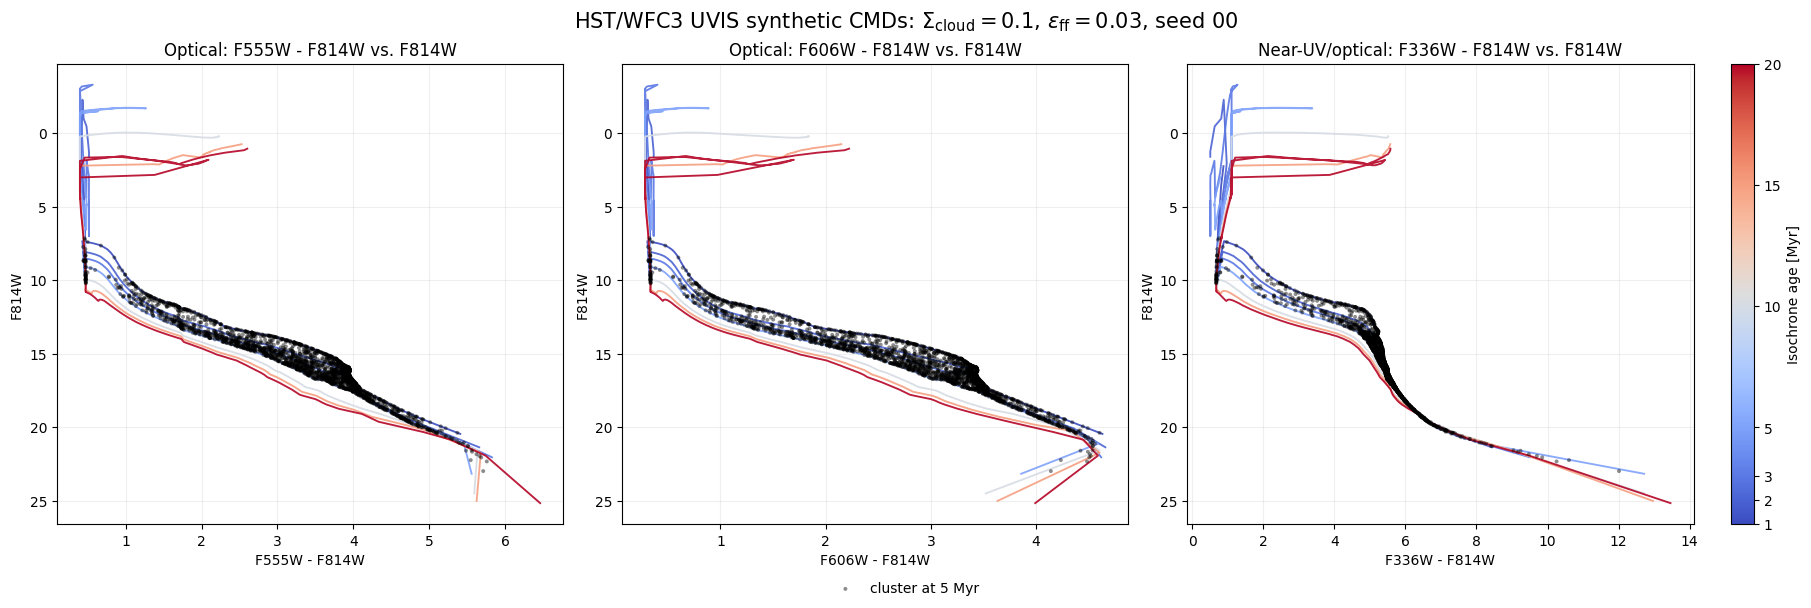

In [12]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6),
    constrained_layout=True,
)

for ax, definition in zip(axes, CMD_DEFINITIONS):
    plot_cmd_panel(
        ax,
        definition,
        ISO_GRID,
        df_cluster,
    )

cluster_handle, cluster_label = axes[0].get_legend_handles_labels()
if cluster_handle:
    fig.legend(
        cluster_handle,
        cluster_label,
        loc="outside lower center",
        frameon=False,
    )

age_mappable = make_age_mappable()
age_colorbar = fig.colorbar(
    age_mappable,
    ax=axes,
    orientation="vertical",
    fraction=0.025,
    pad=0.02,
)
age_colorbar.set_label("Isochrone age [Myr]")
age_colorbar.set_ticks(PLOT_AGES_MYR)

fig.suptitle(
    r"HST/WFC3 UVIS synthetic CMDs: "
    r"$\Sigma_{\rm cloud}=0.1$, "
    r"$\epsilon_{\rm ff}=0.03$, seed 00",
    fontsize=15,
)

finish_figure(
    fig,
    "hst_optical_uv_cmds_sigma0p1_eff0p03_seed00_t5myr.png",
)

## Save each CMD separately

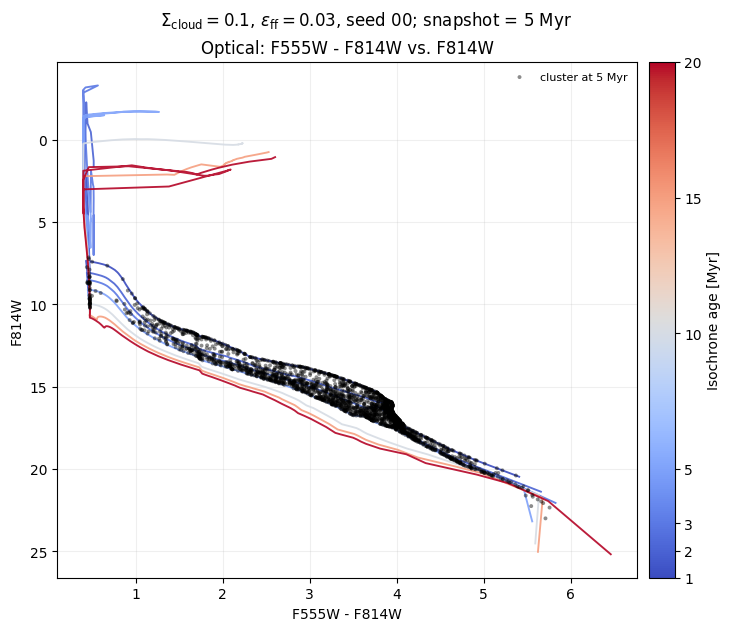

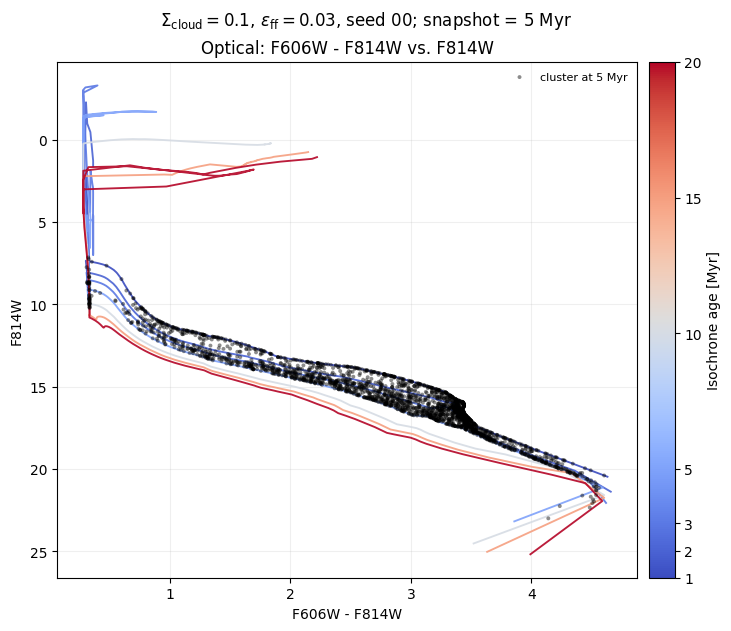

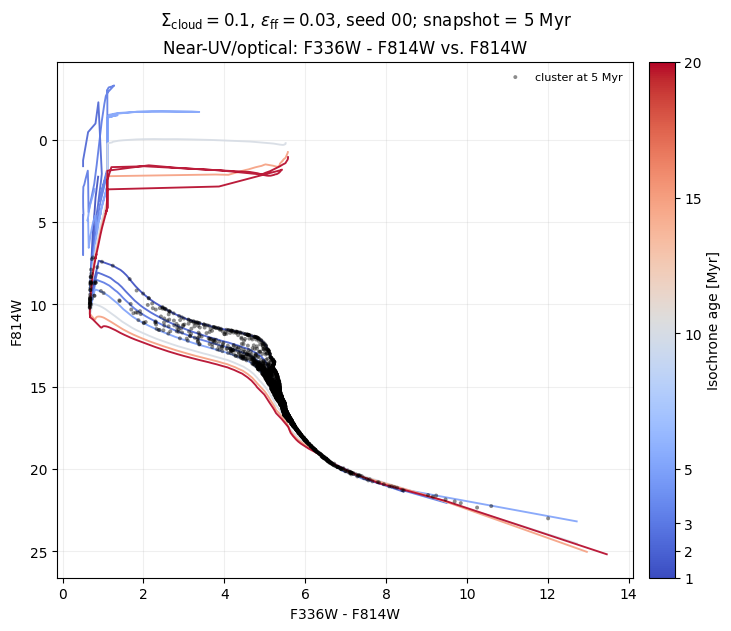

In [13]:
for definition in CMD_DEFINITIONS:
    fig, ax = plt.subplots(
        figsize=(7.2, 6.2),
        constrained_layout=True,
    )

    plot_cmd_panel(
        ax,
        definition,
        ISO_GRID,
        df_cluster,
    )

    ax.legend(
        fontsize=8,
        frameon=False,
    )

    age_colorbar = fig.colorbar(
        make_age_mappable(),
        ax=ax,
        orientation="vertical",
        pad=0.02,
    )
    age_colorbar.set_label("Isochrone age [Myr]")
    age_colorbar.set_ticks(PLOT_AGES_MYR)

    fig.suptitle(
        r"$\Sigma_{\rm cloud}=0.1$, "
        r"$\epsilon_{\rm ff}=0.03$, seed 00; "
        f"snapshot = {SNAPSHOT_TIME_MYR:g} Myr"
    )

    filename = (
        definition["name"]
        .lower()
        .replace("-", "_")
        + "_vs_"
        + definition["y"].lower()
        + ".png"
    )

    finish_figure(fig, filename)

## Output summary

In [14]:
print(f"Figures and photometry saved in: {OUTPUT_DIR.resolve()}")
print("Created CMDs:")
for definition in CMD_DEFINITIONS:
    print(f"  {definition['title']}")

Figures and photometry saved in: /sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/07-29_optical-uv-cmds/hst_optical_uv_cmd_outputs
Created CMDs:
  Optical: F555W - F814W vs. F814W
  Optical: F606W - F814W vs. F814W
  Near-UV/optical: F336W - F814W vs. F814W
